AQI records: (1827, 15)
Matched records: (543, 3)
        Date   AQI  Satellite_Pollution_Coverage
0 2020-04-01  17.3                     34.091187
1 2020-04-03  67.5                     33.610535
2 2020-04-05  17.5                     52.111816
3 2020-04-07  25.6                     65.611267
4 2020-04-09  75.2                     44.937134
Correlation: 0.1310522629610768
P-value: 0.002213394264928828


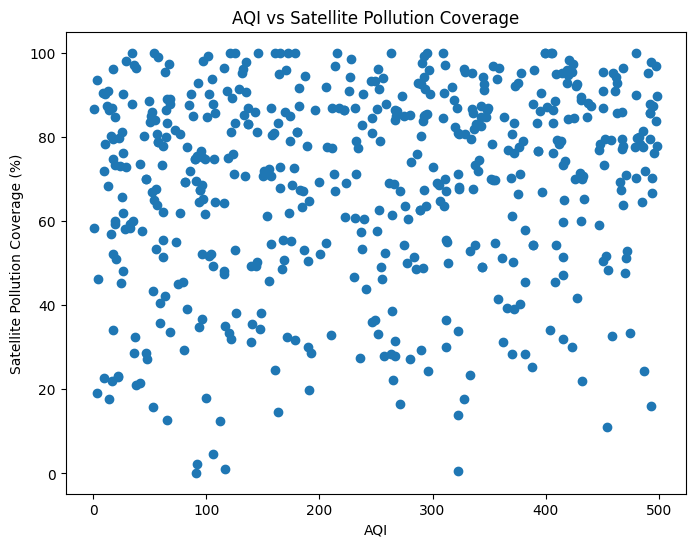


HIGH AQI DAYS
          Date    AQI  Satellite_Pollution_Coverage
79  2020-07-11  499.0                     89.830017
300 2021-05-05  498.2                     77.871704
462 2024-06-30  497.9                     96.864319
22  2020-08-15  497.9                     83.834839
383 2024-08-25  495.9                     76.171875
18  2020-08-07  495.3                     87.286377
302 2021-05-09  494.5                     70.242310
483 2024-05-11  493.8                     66.654968
177 2020-09-29  493.4                     16.040039
434 2024-07-12  493.3                     97.798157

LOW AQI DAYS
          Date   AQI  Satellite_Pollution_Coverage
262 2021-07-21   0.4                     86.712646
73  2020-01-29   0.5                     58.312988
195 2021-08-05   2.8                     93.626404
478 2024-05-01   3.3                     18.998718
155 2020-10-15   4.3                     46.299744
101 2020-06-25   8.8                     90.412903
148 2020-10-01   9.2                     2

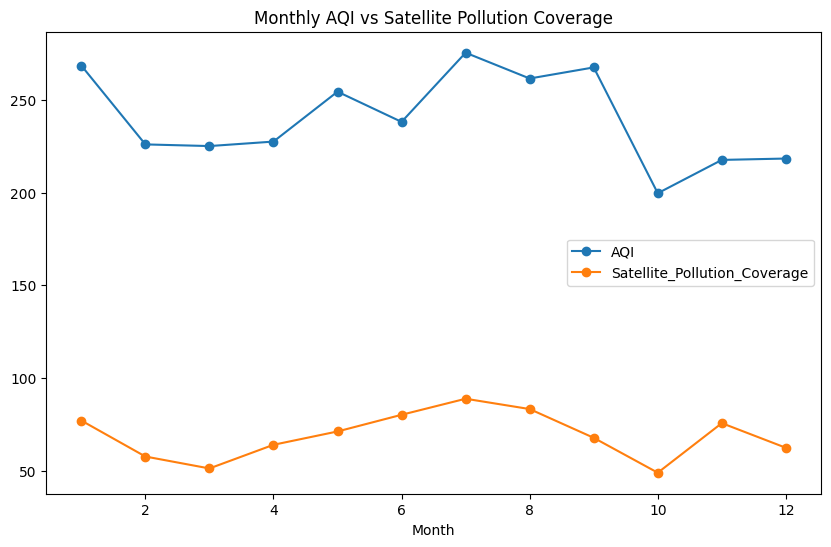

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy.stats import pearsonr

# =========================
# LOAD AQI DATA
# =========================
df = pd.read_csv("../data/cleaned_aqi_final.csv")

df['Date'] = pd.to_datetime(df['Date'])

print("AQI records:", df.shape)

# =========================
# SATELLITE FOLDER
# =========================
base_folder = "../satellite images"

results = []

# =========================
# PROCESS EACH IMAGE
# =========================
for root, dirs, files in os.walk(base_folder):
    for file in files:

        if file.lower().endswith((".png", ".jpg", ".jpeg")):

            try:
                # extract date from filename
                date_str = file.split(".")[0]
                img_date = pd.to_datetime(date_str)

                # image path
                img_path = os.path.join(root, file)

                # load image
                img = Image.open(img_path).convert("RGB")
                img = img.resize((256, 256))

                img_np = np.array(img)

                # enhancement
                enhanced = cv2.convertScaleAbs(
                    img_np,
                    alpha=1.4,
                    beta=20
                )

                # grayscale
                gray = cv2.cvtColor(
                    enhanced,
                    cv2.COLOR_RGB2GRAY
                )

                # threshold hotspot detection
                _, mask = cv2.threshold(
                    gray,
                    180,
                    255,
                    cv2.THRESH_BINARY
                )

                polluted_pixels = np.sum(mask == 255)
                total_pixels = mask.size

                pollution_percent = (
                    polluted_pixels / total_pixels
                ) * 100

                # get AQI
                match = df[df['Date'] == img_date]

                if len(match) > 0:
                    aqi = match['AQI'].values[0]

                    results.append([
                        img_date,
                        aqi,
                        pollution_percent
                    ])

            except:
                pass

# =========================
# RESULTS DF
# =========================
corr_df = pd.DataFrame(
    results,
    columns=[
        'Date',
        'AQI',
        'Satellite_Pollution_Coverage'
    ]
)

print("Matched records:", corr_df.shape)

print(corr_df.head())

# =========================
# CORRELATION
# =========================
corr, pval = pearsonr(
    corr_df['AQI'],
    corr_df['Satellite_Pollution_Coverage']
)

print("Correlation:", corr)
print("P-value:", pval)

# =========================
# SCATTER PLOT
# =========================
plt.figure(figsize=(8,6))

plt.scatter(
    corr_df['AQI'],
    corr_df['Satellite_Pollution_Coverage']
)

plt.xlabel("AQI")
plt.ylabel("Satellite Pollution Coverage (%)")
plt.title("AQI vs Satellite Pollution Coverage")

plt.show()

# =========================
# HIGH VS LOW AQI COMPARISON
# =========================
high = corr_df.sort_values(
    'AQI',
    ascending=False
).head(10)

low = corr_df.sort_values(
    'AQI',
    ascending=True
).head(10)

print("\nHIGH AQI DAYS")
print(high)

print("\nLOW AQI DAYS")
print(low)

# =========================
# MONTHLY COMPARISON
# =========================
corr_df['Month'] = corr_df['Date'].dt.month

monthly = corr_df.groupby('Month')[
    ['AQI', 'Satellite_Pollution_Coverage']
].mean()

print(monthly)

monthly.plot(
    figsize=(10,6),
    marker='o'
)

plt.title("Monthly AQI vs Satellite Pollution Coverage")
plt.show()